# Imports

In [1]:
import os
import json
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd

In [3]:
from alphalens.tears import create_summary_tear_sheet
from alphalens.utils import get_clean_factor_and_forward_returns

In [4]:
data_store=Path("./Prepared_Data_Store")

In [5]:
train_start=pd.to_datetime("2010-02-22")
train_end=pd.to_datetime("2016-02-23")

#### Note: We will Evaluate Signals only on the Training Data and not on Testing Data

# Loading Stocks's Trade Price Data

## Traded Tickers

In [6]:
with open(os.path.join(data_store,"stocks_to_traded.json"),"r") as file:
    traded_tickers=json.load(file)

## Duration of Data

In [7]:
start_date=2009
end_date=2017

In [8]:
idx=pd.IndexSlice

In [9]:
data=pd.read_csv(
    "./Data_Store/wiki_prices.csv",
    parse_dates=["date"],
    index_col=["date","ticker"]
)

In [10]:
data=data.sort_index()

In [11]:
data=data.loc[idx[str(start_date):str(end_date),traded_tickers],"adj_open"]

In [12]:
data=data.swaplevel()
data.index.names=["ticker","date"]

In [13]:
trade_prices=(data
              .shift(-1)
              .unstack("ticker")
              .sort_index()
              .tz_localize("UTC",level="date")
              .ffill()
     )

In [14]:
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2009-01-02 00:00:00+00:00 to 2017-12-29 00:00:00+00:00
Columns: 374 entries, A to FTNT
dtypes: float64(374)
memory usage: 6.5 MB


# Loading Factor's Data

In [15]:
factor_data=pd.read_csv(
    os.path.join(data_store,"factors.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

In [16]:
factor_data=factor_data.loc[idx[train_start:train_end,:]]

In [17]:
factor_data=(factor_data
             .sort_index()
             .tz_localize("UTC",level="date"))

In [18]:
factor_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 565488 entries, (Timestamp('2010-02-22 00:00:00+0000', tz='UTC'), 'A') to (Timestamp('2016-02-23 00:00:00+0000', tz='UTC'), 'ZBRA')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Model1_Factors   565488 non-null  float64
 1   Model4_Factors   565488 non-null  float64
 2   Model2_Factors   565488 non-null  float64
 3   Model3_Factors   565488 non-null  float64
 4   Model8_Factors   565488 non-null  float64
 5   Combined_Factor  565488 non-null  float64
dtypes: float64(6)
memory usage: 28.1+ MB


# Evaluating Signals

In [19]:
quantiles=5
periods=(1,5,7,15,21)

## Model-1

### Factors

In [20]:
model1_factors=factor_data["Model1_Factors"]

In [21]:
model1_factors.info()

<class 'pandas.core.series.Series'>
MultiIndex: 565488 entries, (Timestamp('2010-02-22 00:00:00+0000', tz='UTC'), 'A') to (Timestamp('2016-02-23 00:00:00+0000', tz='UTC'), 'ZBRA')
Series name: Model1_Factors
Non-Null Count   Dtype  
--------------   -----  
565488 non-null  float64
dtypes: float64(1)
memory usage: 6.6+ MB


## Summary Tear Sheet

In [22]:
df=get_clean_factor_and_forward_returns(
    factor=model1_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.282073,0.014616,-0.010083,0.007109,113400,20.053582
2,-0.038311,0.018497,-0.004885,0.004695,113397,20.053052
3,-0.031985,0.022701,-0.002360,0.004514,111891,19.786732
4,-0.026832,0.027229,0.000114,0.004462,113397,20.053052
5,-0.019864,0.207722,0.004945,0.006091,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,0.002,-0.001,-0.000,-0.000,0.000
beta,0.000,0.003,0.009,0.005,0.002
Mean Period Wise Return Top Quantile (bps),0.205,-0.022,-0.003,-0.003,0.002
Mean Period Wise Return Bottom Quantile (bps),0.091,0.027,0.003,0.004,-0.001
Mean Period Wise Spread (bps),0.114,-0.048,-0.006,-0.007,0.004


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.000,-0.002,-0.001,-0.001,0.001
IC Std.,0.051,0.049,0.049,0.050,0.051
Risk-Adjusted IC,-0.004,-0.035,-0.018,-0.012,0.012
t-stat(IC),-0.163,-1.357,-0.716,-0.466,0.464
p-value(IC),0.870,0.175,0.474,0.641,0.642
IC Skew,0.060,0.019,0.032,0.010,0.010
IC Kurtosis,-0.152,-0.260,-0.294,0.106,-0.071


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.607,0.736,0.725,0.796,0.770
Quantile 2 Mean Turnover,0.749,0.784,0.785,0.796,0.793
Quantile 3 Mean Turnover,0.768,0.784,0.786,0.790,0.793
Quantile 4 Mean Turnover,0.748,0.781,0.776,0.796,0.792
Quantile 5 Mean Turnover,0.598,0.755,0.754,0.794,0.772


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.368,0.08,0.095,-0.024,0.041


<Figure size 640x480 with 0 Axes>

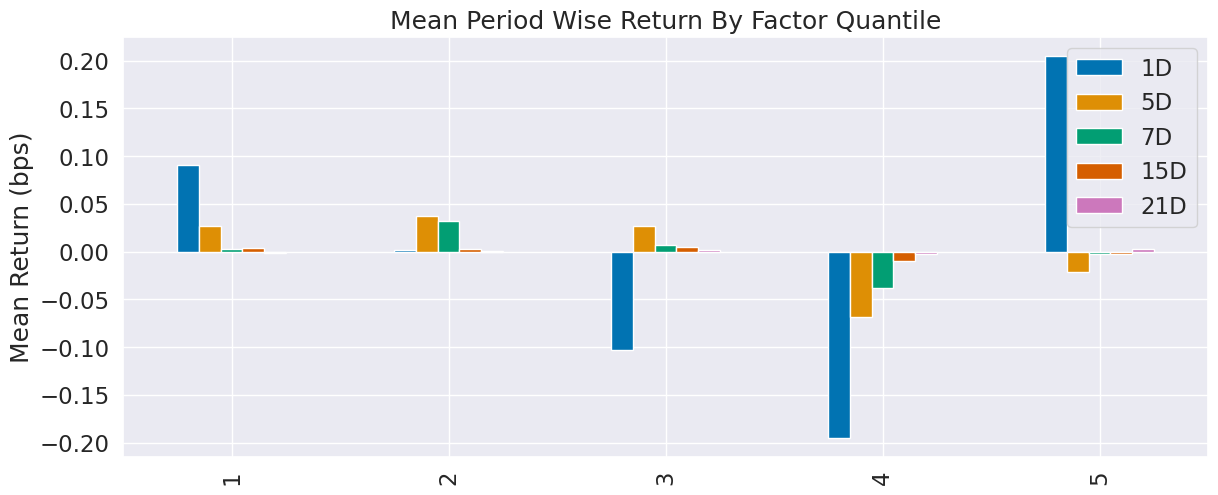

In [23]:
create_summary_tear_sheet(df)

## Model-4

### Factors

In [24]:
model4_factors=factor_data["Model4_Factors"]

### Summary Tear Sheet

In [25]:
df=get_clean_factor_and_forward_returns(
    factor=model4_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.289855,0.014296,-0.008533,0.006888,113400,20.053582
2,-0.037164,0.018623,-0.003515,0.004341,113397,20.053052
3,-0.030385,0.021763,-0.001149,0.004078,111891,19.786732
4,-0.025245,0.026192,0.001120,0.003949,113397,20.053052
5,-0.018643,0.184415,0.005423,0.005273,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,0.002,-0.001,-0.001,-0.000,-0.000
beta,0.003,0.007,0.012,0.014,0.011
Mean Period Wise Return Top Quantile (bps),0.273,-0.006,0.005,-0.000,0.003
Mean Period Wise Return Bottom Quantile (bps),-0.048,0.067,0.048,0.010,0.002
Mean Period Wise Spread (bps),0.321,-0.073,-0.043,-0.010,0.002


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.001,-0.002,-0.001,-0.001,-0.000
IC Std.,0.052,0.049,0.049,0.050,0.052
Risk-Adjusted IC,-0.011,-0.036,-0.027,-0.029,-0.006
t-stat(IC),-0.420,-1.391,-1.046,-1.143,-0.225
p-value(IC),0.675,0.164,0.296,0.253,0.822
IC Skew,0.032,0.070,0.036,-0.001,0.002
IC Kurtosis,-0.114,-0.212,-0.204,-0.017,-0.142


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.614,0.733,0.728,0.804,0.782
Quantile 2 Mean Turnover,0.753,0.784,0.785,0.797,0.794
Quantile 3 Mean Turnover,0.767,0.784,0.784,0.790,0.794
Quantile 4 Mean Turnover,0.749,0.778,0.776,0.795,0.791
Quantile 5 Mean Turnover,0.619,0.751,0.755,0.808,0.781


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.343,0.085,0.091,-0.05,0.018


<Figure size 640x480 with 0 Axes>

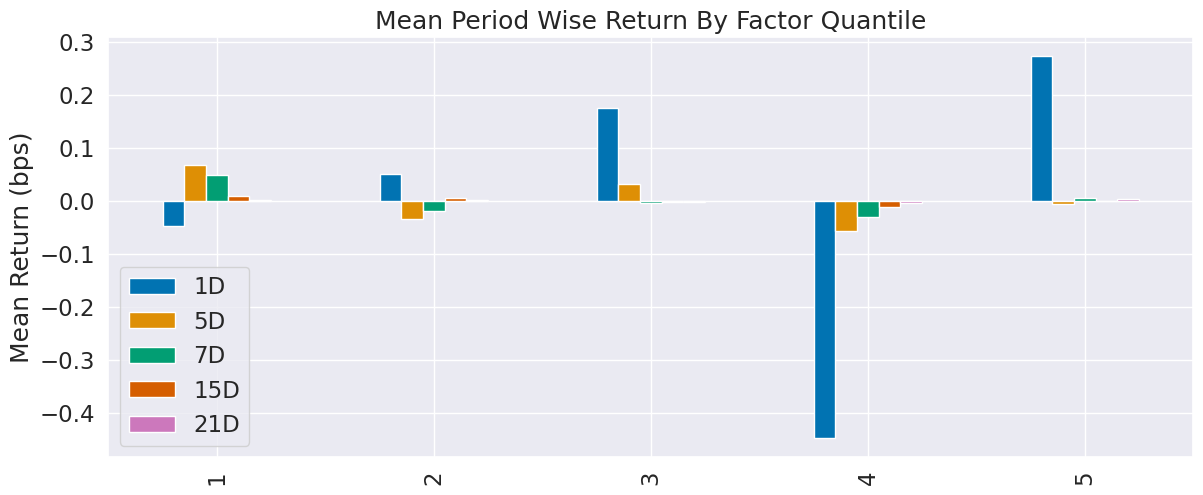

In [26]:
create_summary_tear_sheet(df)

## Model-2

### Factors

In [27]:
model2_factors=factor_data["Model2_Factors"]

### Summary Tear Sheet

In [28]:
df=get_clean_factor_and_forward_returns(
    factor=model2_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.276796,0.012562,-0.009972,0.007046,113400,20.053582
2,-0.038076,0.016463,-0.004846,0.004597,113397,20.053052
3,-0.032070,0.020107,-0.002371,0.004410,111891,19.786732
4,-0.026153,0.025183,0.000045,0.004348,113397,20.053052
5,-0.019703,0.208656,0.004774,0.005964,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,0.001,-0.001,-0.000,0.000,0.000
beta,-0.000,0.003,0.008,0.005,0.002
Mean Period Wise Return Top Quantile (bps),0.093,-0.032,-0.001,0.002,0.004
Mean Period Wise Return Bottom Quantile (bps),0.229,0.026,0.013,0.003,-0.001
Mean Period Wise Spread (bps),-0.136,-0.057,-0.014,-0.002,0.005


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,0.000,-0.001,-0.000,-0.000,0.001
IC Std.,0.050,0.049,0.050,0.050,0.052
Risk-Adjusted IC,0.001,-0.025,-0.010,-0.002,0.018
t-stat(IC),0.038,-0.964,-0.385,-0.097,0.683
p-value(IC),0.970,0.335,0.700,0.923,0.495
IC Skew,0.056,-0.022,0.016,0.003,0.014
IC Kurtosis,-0.200,-0.260,-0.288,0.054,-0.068


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.607,0.732,0.721,0.795,0.767
Quantile 2 Mean Turnover,0.747,0.782,0.784,0.795,0.794
Quantile 3 Mean Turnover,0.767,0.785,0.786,0.790,0.793
Quantile 4 Mean Turnover,0.748,0.779,0.776,0.795,0.793
Quantile 5 Mean Turnover,0.599,0.747,0.752,0.790,0.765


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.368,0.092,0.103,-0.015,0.053


<Figure size 640x480 with 0 Axes>

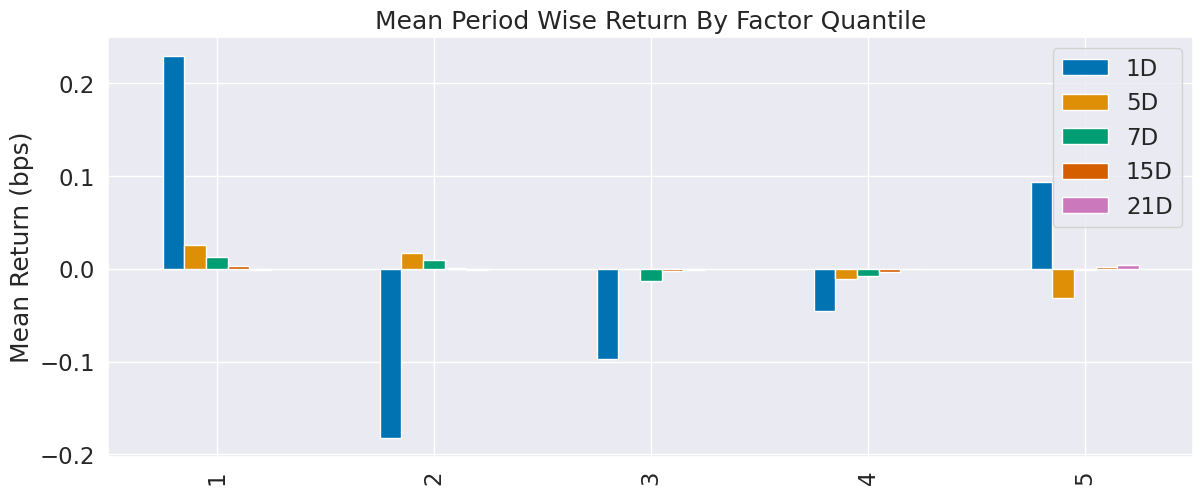

In [29]:
create_summary_tear_sheet(df)

## Model-3

### Factors

In [30]:
model3_factors=factor_data["Model3_Factors"]

### Summary Tear Sheet

In [31]:
df=get_clean_factor_and_forward_returns(
    factor=model3_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.282519,0.011176,-0.009065,0.006863,113400,20.053582
2,-0.025838,0.015405,-0.004545,0.003623,113397,20.053052
3,-0.020282,0.019604,-0.002456,0.003462,111891,19.786732
4,-0.016397,0.026352,-0.000422,0.003424,113397,20.053052
5,-0.012854,0.221522,0.003933,0.006188,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.009,-0.002,-0.001,0.000,0.000
beta,0.000,0.004,0.008,-0.000,-0.004
Mean Period Wise Return Top Quantile (bps),-0.558,-0.096,-0.050,-0.015,-0.003
Mean Period Wise Return Bottom Quantile (bps),-0.009,0.008,-0.014,-0.008,-0.006
Mean Period Wise Spread (bps),-0.549,-0.104,-0.036,-0.007,0.003


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.001,-0.003,-0.002,-0.001,0.000
IC Std.,0.050,0.052,0.052,0.051,0.053
Risk-Adjusted IC,-0.018,-0.053,-0.033,-0.027,0.005
t-stat(IC),-0.707,-2.078,-1.294,-1.036,0.180
p-value(IC),0.480,0.038,0.196,0.300,0.857
IC Skew,0.044,-0.076,-0.144,-0.068,0.023
IC Kurtosis,-0.040,-0.190,-0.154,0.024,-0.023


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.495,0.701,0.726,0.791,0.747
Quantile 2 Mean Turnover,0.704,0.771,0.779,0.798,0.791
Quantile 3 Mean Turnover,0.732,0.776,0.781,0.791,0.791
Quantile 4 Mean Turnover,0.701,0.765,0.770,0.791,0.784
Quantile 5 Mean Turnover,0.490,0.726,0.753,0.817,0.776


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.553,0.14,0.086,-0.055,0.056


<Figure size 640x480 with 0 Axes>

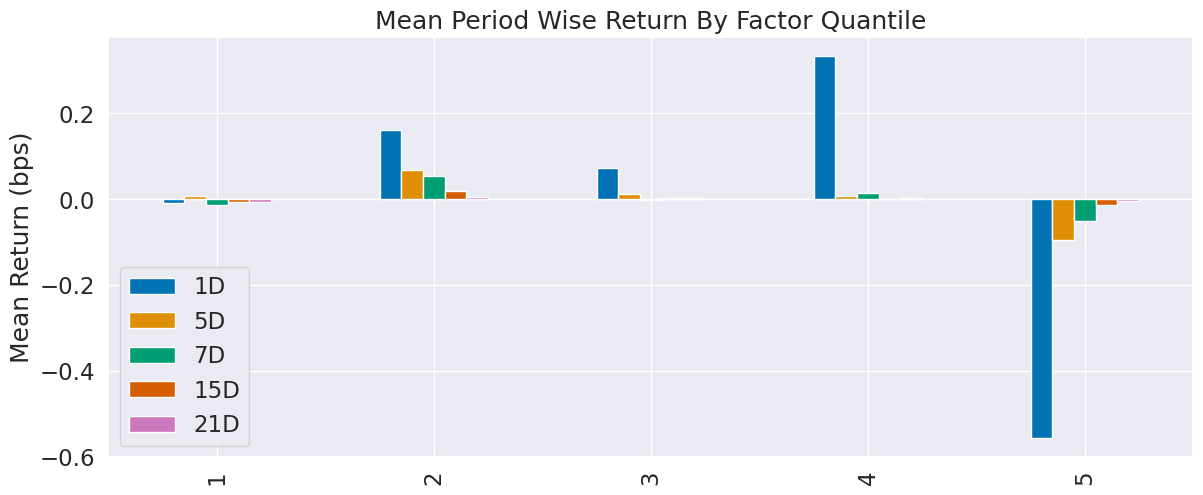

In [32]:
create_summary_tear_sheet(df)

## Model-8

### Factors

In [33]:
model8_factors=factor_data["Model8_Factors"]

### Summary Tear Sheet

In [34]:
df=get_clean_factor_and_forward_returns(
    factor=model8_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.259841,0.014045,-0.008899,0.007348,113400,20.053582
2,-0.095480,0.017725,-0.003707,0.004837,113397,20.053052
3,-0.075453,0.022308,-0.001224,0.004447,111891,19.786732
4,-0.056292,0.030201,0.001195,0.004235,113397,20.053052
5,-0.036974,0.220947,0.005878,0.005828,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,0.004,-0.001,-0.000,-0.000,-0.000
beta,0.000,0.007,0.013,0.013,0.010
Mean Period Wise Return Top Quantile (bps),0.674,-0.021,0.004,-0.003,0.001
Mean Period Wise Return Bottom Quantile (bps),0.097,0.030,0.022,0.002,-0.002
Mean Period Wise Spread (bps),0.577,-0.051,-0.019,-0.005,0.003


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,0.000,-0.001,-0.001,-0.001,0.000
IC Std.,0.052,0.050,0.051,0.051,0.052
Risk-Adjusted IC,0.002,-0.026,-0.012,-0.016,0.000
t-stat(IC),0.073,-1.027,-0.470,-0.615,0.003
p-value(IC),0.942,0.304,0.638,0.538,0.998
IC Skew,0.085,0.111,0.071,0.140,0.127
IC Kurtosis,-0.105,-0.277,-0.279,-0.112,-0.036


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.673,0.729,0.733,0.801,0.777
Quantile 2 Mean Turnover,0.769,0.785,0.784,0.796,0.795
Quantile 3 Mean Turnover,0.778,0.786,0.787,0.791,0.794
Quantile 4 Mean Turnover,0.768,0.780,0.781,0.794,0.793
Quantile 5 Mean Turnover,0.674,0.752,0.759,0.802,0.779


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.227,0.091,0.085,-0.04,0.026


<Figure size 640x480 with 0 Axes>

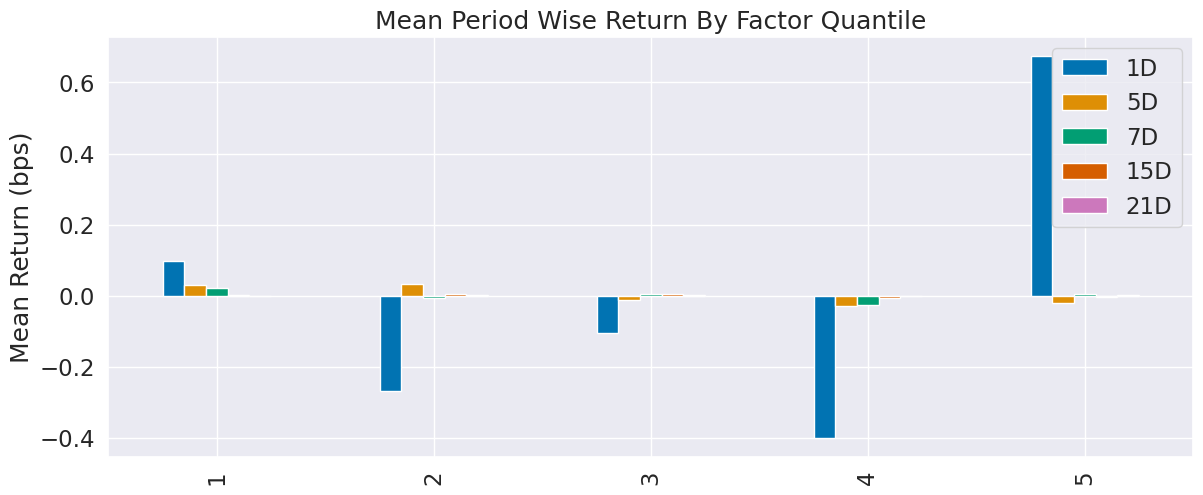

In [35]:
create_summary_tear_sheet(df)

## Combined-Model

### Factors

In [36]:
combined_factors=factor_data["Combined_Factor"]

### Summary Tear Sheet

In [37]:
df=get_clean_factor_and_forward_returns(
    factor=combined_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.271312,0.012009,-0.008779,0.006579,113400,20.053582
2,-0.035590,0.015448,-0.004126,0.004130,113397,20.053052
3,-0.029160,0.018969,-0.001915,0.003942,111891,19.786732
4,-0.024157,0.022648,0.000233,0.003876,113397,20.053052
5,-0.018127,0.191694,0.004466,0.005442,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,0.000,-0.001,-0.001,-0.000,0.000
beta,0.001,0.005,0.011,0.008,0.005
Mean Period Wise Return Top Quantile (bps),0.392,-0.024,-0.001,-0.001,0.002
Mean Period Wise Return Bottom Quantile (bps),0.362,0.063,0.026,0.006,-0.001
Mean Period Wise Spread (bps),0.031,-0.087,-0.027,-0.007,0.003


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.000,-0.002,-0.001,-0.001,0.000
IC Std.,0.051,0.050,0.050,0.051,0.052
Risk-Adjusted IC,-0.007,-0.038,-0.021,-0.015,0.009
t-stat(IC),-0.259,-1.477,-0.813,-0.580,0.366
p-value(IC),0.795,0.140,0.417,0.562,0.714
IC Skew,0.051,0.043,0.019,0.015,0.028
IC Kurtosis,-0.138,-0.233,-0.298,0.037,-0.088


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.602,0.727,0.723,0.807,0.768
Quantile 2 Mean Turnover,0.748,0.782,0.782,0.796,0.792
Quantile 3 Mean Turnover,0.767,0.785,0.784,0.791,0.794
Quantile 4 Mean Turnover,0.747,0.777,0.774,0.796,0.790
Quantile 5 Mean Turnover,0.593,0.748,0.754,0.806,0.774


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.378,0.096,0.096,-0.05,0.041


<Figure size 640x480 with 0 Axes>

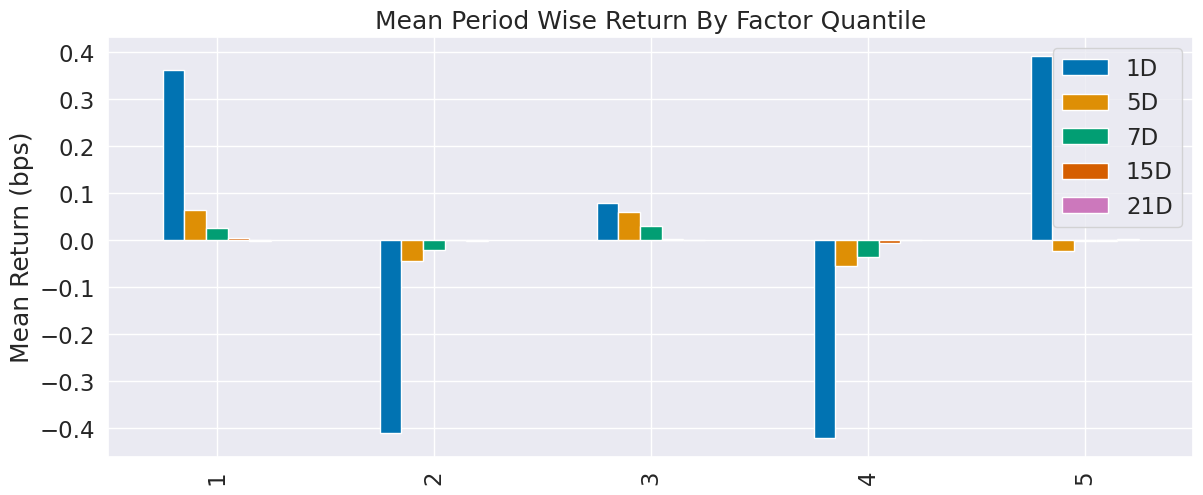

In [38]:
create_summary_tear_sheet(df)

# END